In [14]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


PROJECT_DIR = Path(
    r"A:\NCA_DATA\Validation\2018_HarmonicSensitivity"
)

DERIVED_DIR = PROJECT_DIR / "Derived_AmpPhase_TIFs"

K2_CSV = DERIVED_DIR / "2018_K2_PlotLevel_InterceptAmpPhase.csv"
K3_CSV = DERIVED_DIR / "2018_K3_PlotLevel_InterceptAmpPhase.csv"

OBS_WIDE_CSV = PROJECT_DIR / "PointSampling" / "S2_2018_NCA_117Point_HarmonicInputObservations_WIDE.csv"

In [15]:
k2 = pd.read_csv(K2_CSV)
k3 = pd.read_csv(K3_CSV)
obs = pd.read_csv(OBS_WIDE_CSV)

print("K2:", k2.shape)
print("K3:", k3.shape)
print("Observations:", obs.shape)

print("\nK2 columns:")
print(k2.columns.tolist())

print("\nK3 columns:")
print(k3.columns.tolist())

print("\nObservation columns:")
print(obs.columns.tolist())

K2: (122, 96)
K3: (122, 126)
Observations: (117, 2116)

K2 columns:
['PlotID', 'Year', 'HarmonicOrder', 'X', 'Y', 'constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6', 'constant_B7', 'constant_B8', 'constant_B8A', 'constant_B11', 'constant_B12', 'constant_NDVI', 'constant_NDMI', 'constant_NDRE', 'constant_BSI', 'constant_NBR2', 'amp1_B2', 'amp1_B3', 'amp1_B4', 'amp1_B5', 'amp1_B6', 'amp1_B7', 'amp1_B8', 'amp1_B8A', 'amp1_B11', 'amp1_B12', 'amp1_NDVI', 'amp1_NDMI', 'amp1_NDRE', 'amp1_BSI', 'amp1_NBR2', 'phase1_B2', 'phase1_B3', 'phase1_B4', 'phase1_B5', 'phase1_B6', 'phase1_B7', 'phase1_B8', 'phase1_B8A', 'phase1_B11', 'phase1_B12', 'phase1_NDVI', 'phase1_NDMI', 'phase1_NDRE', 'phase1_BSI', 'phase1_NBR2', 'amp2_B2', 'amp2_B3', 'amp2_B4', 'amp2_B5', 'amp2_B6', 'amp2_B7', 'amp2_B8', 'amp2_B8A', 'amp2_B11', 'amp2_B12', 'amp2_NDVI', 'amp2_NDMI', 'amp2_NDRE', 'amp2_BSI', 'amp2_NBR2', 'phase2_B2', 'phase2_B3', 'phase2_B4', 'phase2_B5', 'phase2_B6', 'phase2_B7', 'phase2_B8

In [31]:
# ---------------------------------------------------------------------
# FILTER VEGETATION DATA TO 2018, THEN JOIN TO K2 + K3
# ---------------------------------------------------------------------

VEG_CSV = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg.csv"
)

veg_raw = pd.read_csv(VEG_CSV)

# Standardize vegetation join-key name
veg_raw = veg_raw.rename(columns={"Plot": "PlotID"})


# ---------------------------------------------------------------------
# NORMALIZE PlotID TYPES
# ---------------------------------------------------------------------

def normalize_plot_id(series):
    return (
        series
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


veg_raw["PlotID"] = normalize_plot_id(veg_raw["PlotID"])
k2["PlotID"] = normalize_plot_id(k2["PlotID"])
k3["PlotID"] = normalize_plot_id(k3["PlotID"])


# ---------------------------------------------------------------------
# FUNCTIONAL-GROUP RESPONSES
# ---------------------------------------------------------------------

FUNCTIONAL_GROUPS = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "PBG_FG",
    "SHRUB_total",
]


# ---------------------------------------------------------------------
# FILTER VEGETATION TO 2018 FIRST
# ---------------------------------------------------------------------

if "Year" not in veg_raw.columns:
    raise KeyError(
        "Vegetation CSV does not contain a 'Year' column."
    )

veg_2018 = (
    veg_raw.loc[veg_raw["Year"] == 2018]
    .copy()
)

print("Raw vegetation table:", veg_raw.shape)
print("2018 vegetation rows:", veg_2018.shape)
print("2018 unique PlotIDs:", veg_2018["PlotID"].nunique())


# ---------------------------------------------------------------------
# CHECK REQUIRED COLUMNS
# ---------------------------------------------------------------------

required_cols = [
    "PlotID",
] + FUNCTIONAL_GROUPS

missing = [
    c for c in required_cols
    if c not in veg_2018.columns
]

if missing:
    raise KeyError(
        f"2018 vegetation table is missing expected columns: {missing}"
    )


# ---------------------------------------------------------------------
# CHECK FOR DUPLICATES WITHIN 2018
# ---------------------------------------------------------------------

dup_counts = veg_2018["PlotID"].value_counts()

duplicate_ids = dup_counts[
    dup_counts > 1
]

print(
    "\nDuplicate PlotIDs remaining within 2018:",
    len(duplicate_ids)
)

if len(duplicate_ids) > 0:
    display(
        veg_2018.loc[
            veg_2018["PlotID"].isin(duplicate_ids.index),
            required_cols
        ]
        .sort_values("PlotID")
    )

    raise ValueError(
        "Duplicate PlotIDs remain within 2018. "
        "Resolve these before modeling."
    )


# ---------------------------------------------------------------------
# BUILD 2018 VEGETATION MODELING TABLE
# ---------------------------------------------------------------------

veg = (
    veg_2018[required_cols]
    .copy()
)

print("\n2018 vegetation modeling table:", veg.shape)
print(
    "Unique 2018 vegetation PlotIDs:",
    veg["PlotID"].nunique()
)


# ---------------------------------------------------------------------
# MATCHING QA BEFORE JOIN
# ---------------------------------------------------------------------

k2_matches = set(k2["PlotID"]) & set(veg["PlotID"])
k3_matches = set(k3["PlotID"]) & set(veg["PlotID"])

k2_unmatched = sorted(
    set(k2["PlotID"]) - set(veg["PlotID"])
)

k3_unmatched = sorted(
    set(k3["PlotID"]) - set(veg["PlotID"])
)

print("\nMatching PlotIDs:")
print("K2 ∩ 2018 Veg:", len(k2_matches))
print("K3 ∩ 2018 Veg:", len(k3_matches))

print("\nUnmatched harmonic plots:")
print("K2:", k2_unmatched)
print("K3:", k3_unmatched)


# ---------------------------------------------------------------------
# JOIN 2018 VEGETATION RESPONSES TO K2 + K3
# ---------------------------------------------------------------------

k2_model = k2.merge(
    veg,
    on="PlotID",
    how="inner",
    validate="one_to_one",
)

k3_model = k3.merge(
    veg,
    on="PlotID",
    how="inner",
    validate="one_to_one",
)


# ---------------------------------------------------------------------
# FINAL JOIN QA
# ---------------------------------------------------------------------

print("\nK2 modeling table:", k2_model.shape)
print("K3 modeling table:", k3_model.shape)

print(
    "K2 joined plots:",
    k2_model["PlotID"].nunique()
)

print(
    "K3 joined plots:",
    k3_model["PlotID"].nunique()
)


# Hard guard against accidentally reintroducing the stale all-year join
EXPECTED_N = 117

assert len(k2_model) == EXPECTED_N, (
    f"K2 has {len(k2_model)} rows; expected {EXPECTED_N}."
)

assert len(k3_model) == EXPECTED_N, (
    f"K3 has {len(k3_model)} rows; expected {EXPECTED_N}."
)


# ---------------------------------------------------------------------
# RESPONSE QA
# ---------------------------------------------------------------------

print("\nFunctional-group availability:")

for fg in FUNCTIONAL_GROUPS:
    print(
        f"{fg:15s} "
        f"K2 n={k2_model[fg].notna().sum():3d} | "
        f"K3 n={k3_model[fg].notna().sum():3d} | "
        f"unique={k2_model[fg].nunique(dropna=True)}"
    )


# ---------------------------------------------------------------------
# PREVIEW
# ---------------------------------------------------------------------

display(
    k2_model[
        ["PlotID", "Year"] + FUNCTIONAL_GROUPS
    ].head()
)

Raw vegetation table: (717, 86)
2018 vegetation rows: (234, 86)
2018 unique PlotIDs: 234

Duplicate PlotIDs remaining within 2018: 0

2018 vegetation modeling table: (234, 8)
Unique 2018 vegetation PlotIDs: 234

Matching PlotIDs:
K2 ∩ 2018 Veg: 117
K3 ∩ 2018 Veg: 117

Unmatched harmonic plots:
K2: ['100', '121', '196', '211', '220']
K3: ['100', '121', '196', '211', '220']

K2 modeling table: (117, 103)
K3 modeling table: (117, 133)
K2 joined plots: 117
K3 joined plots: 117

Functional-group availability:
BAREGROUND_FG   K2 n=117 | K3 n=117 | unique=112
BIOCRUST_FG     K2 n=117 | K3 n=117 | unique=64
EAG_FG          K2 n=117 | K3 n=117 | unique=62
EF_FG           K2 n=117 | K3 n=117 | unique=53
LITTER_FG       K2 n=117 | K3 n=117 | unique=91
PBG_FG          K2 n=117 | K3 n=117 | unique=55
SHRUB_total     K2 n=117 | K3 n=117 | unique=42


,PlotID,Year,BAREGROUND_FG,BIOCRUST_FG,EAG_FG,EF_FG,LITTER_FG,PBG_FG,SHRUB_total
0,101,2018,0.000000,26.12,48.633333,3.400000,5.766667,0.000000,13.950000
1,102,2018,5.160000,44.20,15.100000,9.780000,13.440000,0.400000,11.820000
2,103,2018,0.333333,12.25,74.483333,2.383333,6.800000,0.333333,2.733333
3,104,2018,7.640000,17.56,20.066667,2.033333,30.266667,2.033333,19.050000
4,105,2018,33.140000,10.90,0.000000,1.620000,16.720000,0.820000,36.720000


In [32]:
# ---------------------------------------------------------------------
# IDENTIFY INTERCEPT, AMPLITUDE, AND PHASE PREDICTOR BLOCKS
# ---------------------------------------------------------------------

def identify_iap_columns(df):

    intercept_cols = [
        c for c in df.columns
        if c.lower().startswith(("constant_", "intercept_"))
    ]

    amplitude_cols = [
        c for c in df.columns
        if c.lower().startswith(("amp", "amplitude"))
    ]

    phase_cols = [
        c for c in df.columns
        if c.lower().startswith("phase")
    ]

    return intercept_cols, amplitude_cols, phase_cols


K2_I, K2_A, K2_P = identify_iap_columns(k2_model)
K3_I, K3_A, K3_P = identify_iap_columns(k3_model)


# ------------------------------------------------------------
# QA COUNTS
# ------------------------------------------------------------

print("K2")
print("  Intercepts:", len(K2_I))
print("  Amplitudes:", len(K2_A))
print("  Phases:", len(K2_P))

print("\nK3")
print("  Intercepts:", len(K3_I))
print("  Amplitudes:", len(K3_A))
print("  Phases:", len(K3_P))


# ------------------------------------------------------------
# INSPECT ACTUAL COLUMN NAMES
# ------------------------------------------------------------

print("\nK2 intercept examples:")
print(K2_I[:10])

print("\nK2 amplitude examples:")
print(K2_A[:10])

print("\nK2 phase examples:")
print(K2_P[:10])

print("\nK3 third-order amplitude/phase examples:")
print([c for c in K3_A if "3" in c][:10])
print([c for c in K3_P if "3" in c][:10])

K2
  Intercepts: 15
  Amplitudes: 30
  Phases: 30

K3
  Intercepts: 15
  Amplitudes: 45
  Phases: 45

K2 intercept examples:
['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6', 'constant_B7', 'constant_B8', 'constant_B8A', 'constant_B11', 'constant_B12']

K2 amplitude examples:
['amp1_B2', 'amp1_B3', 'amp1_B4', 'amp1_B5', 'amp1_B6', 'amp1_B7', 'amp1_B8', 'amp1_B8A', 'amp1_B11', 'amp1_B12']

K2 phase examples:
['phase1_B2', 'phase1_B3', 'phase1_B4', 'phase1_B5', 'phase1_B6', 'phase1_B7', 'phase1_B8', 'phase1_B8A', 'phase1_B11', 'phase1_B12']

K3 third-order amplitude/phase examples:
['amp1_B3', 'amp2_B3', 'amp3_B2', 'amp3_B3', 'amp3_B4', 'amp3_B5', 'amp3_B6', 'amp3_B7', 'amp3_B8', 'amp3_B8A']
['phase1_B3', 'phase2_B3', 'phase3_B2', 'phase3_B3', 'phase3_B4', 'phase3_B5', 'phase3_B6', 'phase3_B7', 'phase3_B8', 'phase3_B8A']


In [33]:
# ---------------------------------------------------------------------
# BUILD THE SEVEN I / A / P MODEL PREDICTOR SETS
# ---------------------------------------------------------------------

K2_MODELS = {
    "I":   K2_I,
    "A":   K2_A,
    "P":   K2_P,
    "IA":  K2_I + K2_A,
    "IP":  K2_I + K2_P,
    "AP":  K2_A + K2_P,
    "IAP": K2_I + K2_A + K2_P,
}

K3_MODELS = {
    "I":   K3_I,
    "A":   K3_A,
    "P":   K3_P,
    "IA":  K3_I + K3_A,
    "IP":  K3_I + K3_P,
    "AP":  K3_A + K3_P,
    "IAP": K3_I + K3_A + K3_P,
}


# ------------------------------------------------------------
# QA
# ------------------------------------------------------------

print("K2 predictor sets")
for name, cols in K2_MODELS.items():
    print(f"  {name:3s}: {len(cols):3d} predictors")

print("\nK3 predictor sets")
for name, cols in K3_MODELS.items():
    print(f"  {name:3s}: {len(cols):3d} predictors")


# More precise order-specific QA
print("\nK3 third-order amplitudes:", len(
    [c for c in K3_A if c.startswith("amp3_")]
))

print("K3 third-order phases:", len(
    [c for c in K3_P if c.startswith("phase3_")]
))

K2 predictor sets
  I  :  15 predictors
  A  :  30 predictors
  P  :  30 predictors
  IA :  45 predictors
  IP :  45 predictors
  AP :  60 predictors
  IAP:  75 predictors

K3 predictor sets
  I  :  15 predictors
  A  :  45 predictors
  P  :  45 predictors
  IA :  60 predictors
  IP :  60 predictors
  AP :  90 predictors
  IAP: 105 predictors

K3 third-order amplitudes: 15
K3 third-order phases: 15


In [50]:
# ---------------------------------------------------------------------
# INSPECT PHASE VALUE RANGES
# ---------------------------------------------------------------------

def phase_range_report(df, phase_cols, label):
    vals = df[phase_cols].to_numpy(dtype=float)

    print(label)
    print("  min:", np.nanmin(vals))
    print("  max:", np.nanmax(vals))
    print("  mean:", np.nanmean(vals))
    print("  median:", np.nanmedian(vals))
    print()

phase_range_report(k2_model, K2_P, "K2 phase")
phase_range_report(k3_model, K3_P, "K3 phase")


K2 phase
  min: -3.1396117
  max: 3.1400623
  mean: -0.1319817953810057
  median: -0.127155725

K3 phase
  min: -3.1412444
  max: 3.1415515
  mean: -0.5851630145613984
  median: -1.2615846



In [51]:
# ---------------------------------------------------------------------
# CONVERT PHASE ANGLES TO CIRCULAR SIN/COS PREDICTORS
# ---------------------------------------------------------------------

def circularize_phase_columns(df, phase_cols):
    out = df.copy()
    circular_cols = []

    for col in phase_cols:
        sin_col = f"{col}_sin"
        cos_col = f"{col}_cos"

        out[sin_col] = np.sin(out[col].astype(float))
        out[cos_col] = np.cos(out[col].astype(float))

        circular_cols.extend([sin_col, cos_col])

    return out, circular_cols


k2_model, K2_P_CIRC = circularize_phase_columns(
    k2_model,
    K2_P,
)

k3_model, K3_P_CIRC = circularize_phase_columns(
    k3_model,
    K3_P,
)


print("K2 raw phase columns:", len(K2_P))
print("K2 circular phase predictors:", len(K2_P_CIRC))

print("\nK3 raw phase columns:", len(K3_P))
print("K3 circular phase predictors:", len(K3_P_CIRC))

K2 raw phase columns: 30
K2 circular phase predictors: 60

K3 raw phase columns: 45
K3 circular phase predictors: 90


In [52]:
K2_MODELS = {
    "I":   K2_I,
    "A":   K2_A,
    "P":   K2_P_CIRC,
    "IA":  K2_I + K2_A,
    "IP":  K2_I + K2_P_CIRC,
    "AP":  K2_A + K2_P_CIRC,
    "IAP": K2_I + K2_A + K2_P_CIRC,
}

K3_MODELS = {
    "I":   K3_I,
    "A":   K3_A,
    "P":   K3_P_CIRC,
    "IA":  K3_I + K3_A,
    "IP":  K3_I + K3_P_CIRC,
    "AP":  K3_A + K3_P_CIRC,
    "IAP": K3_I + K3_A + K3_P_CIRC,
}
# ---------------------------------------------------------------------
# QA DIMENSIONALITY
# ---------------------------------------------------------------------

N_K2 = len(k2_model)
N_K3 = len(k3_model)

print(f"K2 observations: {N_K2}")
print(f"K3 observations: {N_K3}")

print("\nK2 predictor sets")
for name, cols in K2_MODELS.items():
    p = len(cols)
    print(
        f"  {name:3s}: "
        f"{p:3d} predictors | "
        f"p/n = {p / N_K2:.3f} | "
        f"n-p = {N_K2 - p:+d}"
    )

print("\nK3 predictor sets")
for name, cols in K3_MODELS.items():
    p = len(cols)
    print(
        f"  {name:3s}: "
        f"{p:3d} predictors | "
        f"p/n = {p / N_K3:.3f} | "
        f"n-p = {N_K3 - p:+d}"
    )

K2 observations: 117
K3 observations: 117

K2 predictor sets
  I  :  15 predictors | p/n = 0.128 | n-p = +102
  A  :  30 predictors | p/n = 0.256 | n-p = +87
  P  :  60 predictors | p/n = 0.513 | n-p = +57
  IA :  45 predictors | p/n = 0.385 | n-p = +72
  IP :  75 predictors | p/n = 0.641 | n-p = +42
  AP :  90 predictors | p/n = 0.769 | n-p = +27
  IAP: 105 predictors | p/n = 0.897 | n-p = +12

K3 predictor sets
  I  :  15 predictors | p/n = 0.128 | n-p = +102
  A  :  45 predictors | p/n = 0.385 | n-p = +72
  P  :  90 predictors | p/n = 0.769 | n-p = +27
  IA :  60 predictors | p/n = 0.513 | n-p = +57
  IP : 105 predictors | p/n = 0.897 | n-p = +12
  AP : 135 predictors | p/n = 1.154 | n-p = -18
  IAP: 150 predictors | p/n = 1.282 | n-p = -33


In [ ]:
#tabling a k-fold CV approach

# ---------------------------------------------------------------------
# FIRST-PASS UNPENALIZED MODEL:
# EAG_FG ACROSS ALL SEVEN K2 PREDICTOR SETS
# ---------------------------------------------------------------------

import statsmodels.api as sm

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error


RESPONSE = "EAG_FG"

CV = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


def cv_ols_score(df, response, predictors, cv):
    """
    Cross-validated ordinary least squares.

    Returns:
        - out-of-fold R²
        - out-of-fold RMSE
        - predictor count
        - matrix rank diagnostics
    """

    valid = (
        df[response].notna()
        & df[predictors].notna().all(axis=1)
    )

    X = df.loc[valid, predictors].astype(float).reset_index(drop=True)
    y = df.loc[valid, response].astype(float).reset_index(drop=True)

    predictions = np.full(len(y), np.nan)

    fold_ranks = []
    fold_predictors = []

    for train_idx, test_idx in cv.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]

        # Add intercept term
        X_train_sm = sm.add_constant(
            X_train,
            has_constant="add",
        )

        X_test_sm = sm.add_constant(
            X_test,
            has_constant="add",
        )

        # Rank diagnostic BEFORE fitting
        rank = np.linalg.matrix_rank(
            X_train_sm.to_numpy()
        )

        fold_ranks.append(rank)
        fold_predictors.append(X_train_sm.shape[1])

        # Unpenalized OLS
        fit = sm.OLS(
            y_train,
            X_train_sm,
        ).fit()

        predictions[test_idx] = fit.predict(
            X_test_sm
        )

    cv_r2 = r2_score(
        y,
        predictions,
    )

    cv_rmse = mean_squared_error(
        y,
        predictions,
    ) ** 0.5

    return {
        "response": response,
        "n": len(y),
        "p": len(predictors),
        "cv_r2": cv_r2,
        "cv_rmse": cv_rmse,
        "min_train_rank": min(fold_ranks),
        "max_train_rank": max(fold_ranks),
        "train_columns": fold_predictors[0],
        "rank_deficient": any(
            rank < ncols
            for rank, ncols
            in zip(fold_ranks, fold_predictors)
        ),
    }


# ---------------------------------------------------------------------
# RUN ALL SEVEN K2 MODELS FOR EAG
# ---------------------------------------------------------------------

eag_k2_results = []

for model_name, predictors in K2_MODELS.items():

    result = cv_ols_score(
        df=k2_model,
        response=RESPONSE,
        predictors=predictors,
        cv=CV,
    )

    result["order"] = "K2"
    result["model"] = model_name

    eag_k2_results.append(result)


eag_k2_results = pd.DataFrame(
    eag_k2_results
)

eag_k2_results = eag_k2_results[
    [
        "order",
        "response",
        "model",
        "n",
        "p",
        "cv_r2",
        "cv_rmse",
        "min_train_rank",
        "max_train_rank",
        "train_columns",
        "rank_deficient",
    ]
]

display(eag_k2_results)

In [40]:
# ---------------------------------------------------------------------
# FIRST-PASS LINEAR MODELS
# FULL-SAMPLE OLS USING NUMPY
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd


def fit_ols_model(
    df,
    response,
    predictors,
    order,
    model_name,
):
    """
    Fit an unpenalized ordinary least-squares model using NumPy.

    Purpose:
        Examine explanatory structure and dimensional behavior
        of the I / A / P predictor blocks.

    No regularization.
    No cross-validation.

    Rank-deficient models are retained and explicitly flagged.
    """

    # ------------------------------------------------------------
    # COMPLETE CASES
    # ------------------------------------------------------------

    cols = [response] + predictors

    dat = (
        df[cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    y = dat[response].to_numpy(dtype=float)

    X_pred = dat[predictors].to_numpy(dtype=float)

    # Add regression intercept
    X = np.column_stack([
        np.ones(len(y)),
        X_pred,
    ])

    n = len(y)
    p = len(predictors)

    # ------------------------------------------------------------
    # MATRIX DIAGNOSTICS
    # ------------------------------------------------------------

    matrix_rank = np.linalg.matrix_rank(X)

    n_columns = X.shape[1]

    rank_deficient = matrix_rank < n_columns

    # Effective residual degrees of freedom should be based on rank,
    # not simply number of nominal columns.
    df_resid = n - matrix_rank

    # ------------------------------------------------------------
    # OLS
    # ------------------------------------------------------------

    beta, residuals_lstsq, rank_lstsq, singular_values = np.linalg.lstsq(
        X,
        y,
        rcond=None,
    )

    y_hat = X @ beta
    resid = y - y_hat

    # ------------------------------------------------------------
    # SUMS OF SQUARES
    # ------------------------------------------------------------

    rss = np.sum(resid ** 2)

    y_mean = np.mean(y)

    tss = np.sum(
        (y - y_mean) ** 2
    )

    if np.isclose(tss, 0):
        r2 = np.nan
    else:
        r2 = 1 - (rss / tss)

    # ------------------------------------------------------------
    # ADJUSTED R²
    #
    # Use effective model rank rather than nominal p when the matrix
    # is rank-deficient.
    #
    # Regression intercept consumes one rank dimension.
    # ------------------------------------------------------------

    effective_predictor_df = matrix_rank - 1

    if (
        np.isnan(r2)
        or df_resid <= 0
        or n <= 1
    ):
        adj_r2 = np.nan

    else:
        adj_r2 = (
            1
            - (1 - r2)
            * (n - 1)
            / df_resid
        )

    # ------------------------------------------------------------
    # ERROR METRICS
    # ------------------------------------------------------------

    rmse = np.sqrt(
        np.mean(resid ** 2)
    )

    # Residual standard error where estimable
    if df_resid > 0:
        residual_se = np.sqrt(
            rss / df_resid
        )
    else:
        residual_se = np.nan

    # ------------------------------------------------------------
    # CONDITION DIAGNOSTIC
    # ------------------------------------------------------------

    if len(singular_values) > 0:
        largest_sv = singular_values[0]
        smallest_sv = singular_values[-1]

        if np.isclose(smallest_sv, 0):
            condition_number = np.inf
        else:
            condition_number = largest_sv / smallest_sv

    else:
        condition_number = np.nan

    # ------------------------------------------------------------
    # RETURN SUMMARY
    # ------------------------------------------------------------

    return {
        "order": order,
        "functional_group": response,
        "model": model_name,

        "n": n,
        "p": p,

        "matrix_columns": n_columns,
        "matrix_rank": matrix_rank,
        "rank_deficient": rank_deficient,

        "effective_predictor_df": effective_predictor_df,
        "df_resid": df_resid,

        "r2": r2,
        "adj_r2": adj_r2,

        "rss": rss,
        "rmse": rmse,
        "residual_se": residual_se,

        "condition_number": condition_number,
    }

In [41]:
# ---------------------------------------------------------------------
# TEST: EAG_FG ACROSS THE SEVEN K2 MODELS
# ---------------------------------------------------------------------

test_results = []

for model_name, predictors in K2_MODELS.items():

    result = fit_ols_model(
        df=k2_model,
        response="EAG_FG",
        predictors=predictors,
        order="K2",
        model_name=model_name,
    )

    test_results.append(result)


test_results = pd.DataFrame(test_results)

display(test_results)

,order,functional_group,model,n,p,matrix_columns,matrix_rank,rank_deficient,effective_predictor_df,df_resid,r2,adj_r2,rss,rmse,residual_se,condition_number
0,K2,EAG_FG,I,116,15,16,16,False,15,100,0.575240,0.511526,32183.216025,16.656576,17.939681,2511.533916
1,K2,EAG_FG,A,116,30,31,31,False,30,85,0.812717,0.746618,14190.028376,11.060191,12.920585,1908.349419
2,K2,EAG_FG,P,116,60,61,61,False,60,55,0.872035,0.732436,9695.677394,9.142397,13.277238,429.924287
3,K2,EAG_FG,IA,116,45,46,46,False,45,70,0.876999,0.797926,9319.569878,8.963321,11.538488,5503.648528
4,K2,EAG_FG,IP,116,75,76,76,False,75,40,0.912008,0.747024,6666.967190,7.581151,12.910235,21207.014445
5,K2,EAG_FG,AP,116,90,91,91,False,90,25,0.965742,0.842411,2595.692545,4.730397,10.189588,22316.353903
6,K2,EAG_FG,IAP,116,105,106,106,False,105,10,0.982269,0.796097,1343.420272,3.403118,11.590601,59250.934077


In [42]:
# ---------------------------------------------------------------------
# IDENTIFY THE ONE DROPPED EAG PLOT
# ---------------------------------------------------------------------

for model_name, predictors in K2_MODELS.items():

    needed = ["PlotID", "EAG_FG"] + predictors

    missing_mask = (
        k2_model[needed]
        .replace([np.inf, -np.inf], np.nan)
        .isna()
        .any(axis=1)
    )

    dropped = k2_model.loc[
        missing_mask,
        ["PlotID"]
    ]

    print(
        f"{model_name:3s}: "
        f"{missing_mask.sum()} dropped | "
        f"{dropped['PlotID'].tolist()}"
    )

I  : 1 dropped | ['115']
A  : 1 dropped | ['115']
P  : 1 dropped | ['115']
IA : 1 dropped | ['115']
IP : 1 dropped | ['115']
AP : 1 dropped | ['115']
IAP: 1 dropped | ['115']


In [43]:
# ---------------------------------------------------------------------
# EAG_FG ACROSS THE SEVEN K3 MODELS
# ---------------------------------------------------------------------

eag_k3_results = []

for model_name, predictors in K3_MODELS.items():

    result = fit_ols_model(
        df=k3_model,
        response="EAG_FG",
        predictors=predictors,
        order="K3",
        model_name=model_name,
    )

    eag_k3_results.append(result)


eag_k3_results = pd.DataFrame(eag_k3_results)

display(eag_k3_results)

,order,functional_group,model,n,p,matrix_columns,matrix_rank,rank_deficient,effective_predictor_df,df_resid,r2,adj_r2,rss,rmse,residual_se,condition_number
0,K3,EAG_FG,I,116,15,16,16,False,15,100,0.574320,0.510468,32252.951715,16.674612,17.959107,2.271005e+03
1,K3,EAG_FG,A,116,45,46,46,False,45,70,0.820052,0.704371,13634.295675,10.841450,13.956205,2.714015e+03
2,K3,EAG_FG,P,116,90,91,91,False,90,25,0.958350,0.808411,3155.720117,5.215792,11.235159,1.317815e+03
3,K3,EAG_FG,IA,116,60,61,61,False,60,55,0.880253,0.749619,9073.031877,8.843969,12.843840,5.299703e+03
4,K3,EAG_FG,IP,116,105,106,106,False,105,10,0.984916,0.826536,1142.872118,3.138845,10.690520,7.154508e+04
5,K3,EAG_FG,AP,116,135,136,115,True,114,1,0.996915,0.645274,233.712200,1.419423,15.287649,inf
6,K3,EAG_FG,IAP,116,150,151,115,True,114,1,0.996915,0.645274,233.712200,1.419423,15.287649,inf


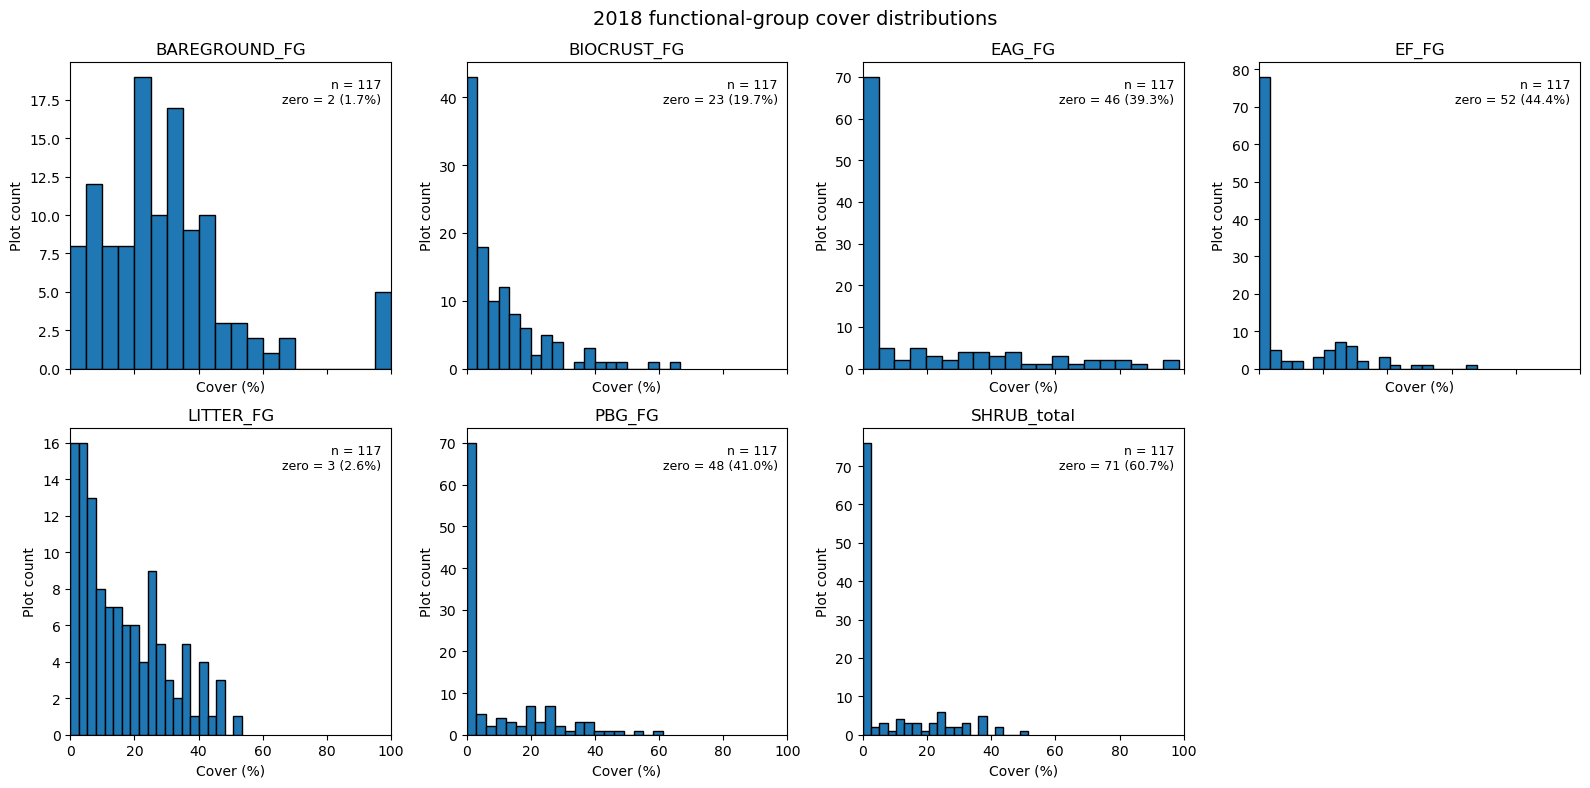

In [44]:
# ---------------------------------------------------------------------
# HISTOGRAMS OF FUNCTIONAL-GROUP COVER
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt

FUNCTIONAL_GROUPS = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "PBG_FG",
    "SHRUB_total",
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
    sharex=True,
)

axes = axes.ravel()

for ax, fg in zip(axes, FUNCTIONAL_GROUPS):

    values = (
        k2_model[fg]
        .dropna()
        .astype(float)
    )

    ax.hist(
        values,
        bins=20,
        edgecolor="black",
    )

    ax.set_title(fg)
    ax.set_xlabel("Cover (%)")
    ax.set_ylabel("Plot count")
    ax.set_xlim(0, 100)

    # Helpful for evaluating zero inflation
    n = len(values)
    n_zero = (values == 0).sum()

    ax.text(
        0.97,
        0.95,
        f"n = {n}\nzero = {n_zero} ({100*n_zero/n:.1f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )


# Remove unused 8th panel
axes[-1].axis("off")

fig.suptitle(
    "2018 functional-group cover distributions",
    fontsize=14,
)

plt.tight_layout()
plt.show()

In [45]:
# ---------------------------------------------------------------------
# VERIFY FUNCTIONAL-GROUP VALUES ARE SAMPLEPOINT COUNT PROPORTIONS
# ---------------------------------------------------------------------

for fg in FUNCTIONAL_GROUPS:

    y = k2_model[fg].dropna().astype(float)

    # If percentages derive from 500 classified points,
    # percent × 5 should be an integer count.
    implied_counts = y * 5

    matches_500 = np.isclose(
        implied_counts,
        np.round(implied_counts),
        atol=1e-8,
    )

    print(
        f"{fg:15s} "
        f"consistent with n=500: "
        f"{matches_500.mean()*100:6.2f}%"
    )


# Check whether the modeled functional groups approximately exhaust
# the classified points.
row_sums = k2_model[FUNCTIONAL_GROUPS].sum(axis=1)

print("\nFunctional-group percentage sums:")
print(row_sums.describe())

BAREGROUND_FG   consistent with n=500:   5.98%
BIOCRUST_FG     consistent with n=500:  27.35%
EAG_FG          consistent with n=500:  50.43%
EF_FG           consistent with n=500:  55.56%
LITTER_FG       consistent with n=500:  16.24%
PBG_FG          consistent with n=500:  56.41%
SHRUB_total     consistent with n=500:  64.96%

Functional-group percentage sums:
count    117.000000
mean      99.591197
std        0.818265
min       92.620000
25%       99.520000
50%       99.920000
75%       99.960000
max      100.020000
dtype: float64


In [48]:
# ---------------------------------------------------------------------
# IMPROVED UNPENALIZED BETA REGRESSION
# ---------------------------------------------------------------------

from scipy.optimize import minimize
from scipy.special import expit, logit, gammaln

import numpy as np
import pandas as pd


def beta_adjust_response(y):
    """
    Smithson-Verkuilen boundary adjustment.

    Input:
        percentage cover on [0, 100]

    Output:
        adjusted proportion strictly inside (0, 1)
    """

    y = np.asarray(y, dtype=float) / 100.0

    n = len(y)

    return (
        y * (n - 1) + 0.5
    ) / n


def beta_neg_loglike(params, X, y):
    """
    Negative log-likelihood for beta regression.

    Mean:
        logit(mu) = X beta

    Precision:
        phi = exp(log_phi)
    """

    beta = params[:-1]
    log_phi = params[-1]

    eta = X @ beta

    mu = expit(eta)

    mu = np.clip(
        mu,
        1e-10,
        1 - 1e-10,
    )

    phi = np.exp(log_phi)

    alpha = mu * phi
    beta_shape = (1 - mu) * phi

    loglik_i = (
        gammaln(phi)
        - gammaln(alpha)
        - gammaln(beta_shape)
        + (alpha - 1) * np.log(y)
        + (beta_shape - 1) * np.log(1 - y)
    )

    if not np.all(np.isfinite(loglik_i)):
        return np.inf

    return -np.sum(loglik_i)


def fit_beta_model(
    df,
    response,
    predictors,
    order,
    model_name,
):
    """
    Unpenalized beta regression with logit link.

    No regularization.
    No cross-validation.

    Large / saturated models are allowed to fail.
    Failure and rank deficiency are retained as diagnostic results.
    """

    # ------------------------------------------------------------
    # COMPLETE CASES
    # ------------------------------------------------------------

    cols = [response] + predictors

    dat = (
        df[cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    y_raw = dat[response].to_numpy(dtype=float)

    y = beta_adjust_response(y_raw)

    X_pred = dat[predictors].to_numpy(dtype=float)

    n = len(y)
    p = len(predictors)


    # ------------------------------------------------------------
    # STANDARDIZE PREDICTORS
    # ------------------------------------------------------------

    means = X_pred.mean(axis=0)

    stds = X_pred.std(
        axis=0,
        ddof=0,
    )

    stds[
        np.isclose(stds, 0)
    ] = 1.0

    X_scaled = (
        X_pred - means
    ) / stds


    # ------------------------------------------------------------
    # ADD REGRESSION INTERCEPT
    # ------------------------------------------------------------

    X = np.column_stack([
        np.ones(n),
        X_scaled,
    ])

    matrix_rank = np.linalg.matrix_rank(X)

    rank_deficient = (
        matrix_rank < X.shape[1]
    )


    # ------------------------------------------------------------
    # BETTER STARTING VALUES
    #
    # Approximate:
    #
    # logit(y*) ≈ X beta
    #
    # This is NOT the final model. It just gives the nonlinear
    # optimizer a much better initial location than all-zero beta.
    # ------------------------------------------------------------

    eta_start = logit(
        np.clip(
            y,
            1e-6,
            1 - 1e-6,
        )
    )

    beta_start, *_ = np.linalg.lstsq(
        X,
        eta_start,
        rcond=None,
    )

    initial_params = np.concatenate([
        beta_start,
        [np.log(20.0)],
    ])


    # ------------------------------------------------------------
    # FIT FULL MODEL
    # ------------------------------------------------------------

    result = minimize(
        beta_neg_loglike,
        initial_params,
        args=(X, y),
        method="L-BFGS-B",
        bounds=[
            (None, None)
        ] * X.shape[1] + [
            (-10, 15)   # bounds on log(phi), not beta coefficients
        ],
        options={
            "maxiter": 10_000,
            "maxfun": 250_000,
            "ftol": 1e-10,
            "gtol": 1e-6,
            "maxls": 50,
        },
    )


    # ------------------------------------------------------------
    # FIT NULL MODEL
    # ------------------------------------------------------------

    X_null = np.ones(
        (n, 1)
    )

    # Starting intercept from transformed response mean
    mu0 = np.clip(
        np.mean(y),
        1e-6,
        1 - 1e-6,
    )

    null_initial = np.array([
        logit(mu0),
        np.log(20.0),
    ])

    null_result = minimize(
        beta_neg_loglike,
        null_initial,
        args=(X_null, y),
        method="L-BFGS-B",
        bounds=[
            (None, None),
            (-10, 15),
        ],
        options={
            "maxiter": 10_000,
            "maxfun": 50_000,
            "ftol": 1e-10,
            "gtol": 1e-6,
        },
    )


    # ------------------------------------------------------------
    # MODEL METRICS
    # ------------------------------------------------------------

    loglik = -beta_neg_loglike(
        result.x,
        X,
        y,
    )

    null_loglik = -beta_neg_loglike(
        null_result.x,
        X_null,
        y,
    )

    delta_loglik = (
        loglik - null_loglik
    )

    lr_vs_null = (
        2 * delta_loglik
    )

    phi_hat = np.exp(
        result.x[-1]
    )

    # beta coefficients + precision parameter
    k_params = len(result.x)

    aic = (
        2 * k_params
        - 2 * loglik
    )

    bic = (
        np.log(n) * k_params
        - 2 * loglik
    )


    # ------------------------------------------------------------
    # RETURN
    # ------------------------------------------------------------

    return {
        "order": order,
        "functional_group": response,
        "model": model_name,

        "n": n,
        "p": p,

        "matrix_columns": X.shape[1],
        "matrix_rank": matrix_rank,
        "rank_deficient": rank_deficient,

        "converged": result.success,
        "optimizer_status": result.status,
        "optimizer_message": result.message,

        "iterations": result.nit,
        "function_evals": result.nfev,

        "loglik": loglik,
        "null_loglik": null_loglik,

        "delta_loglik": delta_loglik,
        "lr_vs_null": lr_vs_null,

        "phi": phi_hat,

        "aic": aic,
        "bic": bic,
    }

In [49]:
# ---------------------------------------------------------------------
# TEST BETA REGRESSION:
# EAG_FG ACROSS ALL SEVEN K2 MODELS
# ---------------------------------------------------------------------

eag_k2_beta = []

for model_name, predictors in K2_MODELS.items():

    result = fit_beta_model(
        df=k2_model,
        response="EAG_FG",
        predictors=predictors,
        order="K2",
        model_name=model_name,
    )

    eag_k2_beta.append(result)

eag_k2_beta = pd.DataFrame(
    eag_k2_beta
)

display(eag_k2_beta)

,order,functional_group,model,n,p,matrix_columns,matrix_rank,rank_deficient,converged,optimizer_status,optimizer_message,iterations,function_evals,loglik,null_loglik,delta_loglik,lr_vs_null,phi,aic,bic
0,K2,EAG_FG,I,116,15,16,16,False,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,309,6138,176.609256,141.156196,35.453060,70.906121,4.171778,-319.218513,-272.407480
1,K2,EAG_FG,A,116,30,31,31,False,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,217,7920,226.682112,141.156196,85.525916,171.051832,14.748268,-389.364224,-301.249337
2,K2,EAG_FG,P,116,60,61,61,False,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,559,37485,247.390465,141.156196,106.234269,212.468538,33.529959,-370.780930,-200.058338
3,K2,EAG_FG,IA,116,45,46,46,False,True,0,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,1330,69360,250.851460,141.156196,109.695264,219.390528,25.446885,-407.702920,-278.284181
4,K2,EAG_FG,IP,116,75,76,76,False,False,1,"STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT",2964,250068,273.192968,141.156196,132.036772,264.073543,64.159027,-392.385935,-180.359491
5,K2,EAG_FG,AP,116,90,91,91,False,False,1,"STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT",2484,250077,354.765714,141.156196,213.609518,427.219036,226.480475,-525.531428,-272.201130
6,K2,EAG_FG,IAP,116,105,106,106,False,False,1,"STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT",2140,250020,382.748082,141.156196,241.591886,483.183773,310.045800,-551.496165,-256.862014
